# Evaluation

This notebook contains the code used to perform the evaluation of the resulting tracking system. We compare, using the so far held-out test sequences, the performance of some different configurations.

In [1]:
import sys
import os
from typing import Any

import torch
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Add the `code` directory to the path.
sys.path.append("../")

import util
import visualize
import dataset
import detect
import kalman
import tracker

In [4]:
# This code is just here so I can reload the external files in case I make
# changes to them after having already imported them.
import importlib

importlib.reload(util)
importlib.reload(visualize)
importlib.reload(dataset)
importlib.reload(detect)
importlib.reload(kalman)
importlib.reload(tracker);

In [3]:
sns.set_theme(style="whitegrid")
plt.rcParams.update(
    {"font.size": 11, "axes.labelsize": 12, "axes.titlesize": 14})

#### Experiments for YOLO Model Size and Camera Count

First, we will run the system on all the test sequences. We will run it using the five available sizes of the YOLO model used by the system and using a different number of available camera views.

In [5]:
data = dataset.CmuPanopticDataset(path="../data/panoptic")

In [11]:
physics = tracker.build_physics()
physics.to(util.DEVICE)

for model in ["yolo26n-pose", "yolo26s-pose", "yolo26m-pose", "yolo26l-pose"]:
    detector = detect.PoseDetector(model_name=model, path="../nets")
    detector.to(util.DEVICE)
    # We only use more than 4 cameras for the smallest model.
    for n_cams in [4, 8, 12, 16] if model == "yolo26n-pose" else [4]:
        for scene in data.test_scenes:
            print(
                f"running for {scene} with {n_cams} cameras using {model}...")
            # Only perform if we don't have the result yet, to enable resuming.
            if not os.path.exists(f"../stats/eval/{model}/{n_cams}/{scene}-times.json"):
                source = data.get_source(scene, num_vga_cams=n_cams)
                source.to(util.DEVICE)
                track = tracker.Tracker(detector, physics)
                cams, frames, fps = track.evaluate(source, progress=0)
                util.save_tracks(
                    f"../stats/eval/{model}/{n_cams}/{scene}.json", cams, frames, fps)
                util.save_json(
                    f"../stats/eval/{model}/{n_cams}/{scene}-times.json", track.timing_stats)

running for 171026_pose3 with 4 cameras using yolo26n-pose...
running for 160906_ian1 with 4 cameras using yolo26n-pose...
running for 170915_office1 with 4 cameras using yolo26n-pose...
running for 161029_build1 with 4 cameras using yolo26n-pose...
running for 160224_haggling1 with 4 cameras using yolo26n-pose...
running for 160906_pizza1 with 4 cameras using yolo26n-pose...
running for 170221_haggling_m3 with 4 cameras using yolo26n-pose...
running for 161029_sports1 with 4 cameras using yolo26n-pose...
running for 171026_pose3 with 8 cameras using yolo26n-pose...
running for 160906_ian1 with 8 cameras using yolo26n-pose...
running for 170915_office1 with 8 cameras using yolo26n-pose...
running for 161029_build1 with 8 cameras using yolo26n-pose...
running for 160224_haggling1 with 8 cameras using yolo26n-pose...
running for 160906_pizza1 with 8 cameras using yolo26n-pose...
running for 170221_haggling_m3 with 8 cameras using yolo26n-pose...
running for 161029_sports1 with 8 cameras 

#### Analysis of Model Size and Camera Count Impact

Next to actually do the evaluation we also need the ground truth tracks. I extract them here ones into the same format as the track predictions, and then we can load them again for computing evaluation metrics.

In [12]:
for scene in data.test_scenes:
    cams_gt, frames_gt, fps_gt = data.load_ground_truth_vga(scene)
    util.save_tracks(f"../stats/gt/{scene}.json", cams_gt, frames_gt, fps_gt)

Before performing visualizations of the results, we need to actually compute the metrics for each evaluation run.

In [13]:
for model in ["yolo26n-pose", "yolo26s-pose", "yolo26m-pose", "yolo26l-pose"]:
    for n_cams in [4, 8, 12, 16] if model == "yolo26n-pose" else [4]:
        for scene in data.test_scenes:
            print(
                f"running for {scene} with {n_cams} cameras using {model}...")
            metrics = util.evaluate_from_files(
                f"../stats/gt/{scene}.json", f"../stats/eval/{model}/{n_cams}/{scene}.json")
            util.save_json(
                f"../stats/eval/{model}/{n_cams}/{scene}-metrics.json", metrics)

running for 171026_pose3 with 4 cameras using yolo26n-pose...
running for 160906_ian1 with 4 cameras using yolo26n-pose...
running for 170915_office1 with 4 cameras using yolo26n-pose...
running for 161029_build1 with 4 cameras using yolo26n-pose...
running for 160224_haggling1 with 4 cameras using yolo26n-pose...
running for 160906_pizza1 with 4 cameras using yolo26n-pose...
running for 170221_haggling_m3 with 4 cameras using yolo26n-pose...
running for 161029_sports1 with 4 cameras using yolo26n-pose...
running for 171026_pose3 with 8 cameras using yolo26n-pose...
running for 160906_ian1 with 8 cameras using yolo26n-pose...
running for 170915_office1 with 8 cameras using yolo26n-pose...
running for 161029_build1 with 8 cameras using yolo26n-pose...
running for 160224_haggling1 with 8 cameras using yolo26n-pose...
running for 160906_pizza1 with 8 cameras using yolo26n-pose...
running for 170221_haggling_m3 with 8 cameras using yolo26n-pose...
running for 161029_sports1 with 8 cameras 

Now that we have the evaluation results for all sequences, we merge them into a large dataset for further processing.

In [16]:
df = []
for model in ["yolo26n-pose", "yolo26s-pose", "yolo26m-pose", "yolo26l-pose"]:
    for scene in data.test_scenes:
        for n_cams in [4, 8, 12, 16] if model == "yolo26n-pose" else [4]:
            metrics = util.load_json(
                f"../stats/eval/{model}/{n_cams}/{scene}-metrics.json")
            times = util.load_json(
                f"../stats/eval/{model}/{n_cams}/{scene}-times.json")
            df.append({
                "model": model, "scene": scene, "n_cams": n_cams,
                "MPJPE": metrics["MPJPE"], "MOTA": metrics["MOTA"],
                "MOTP": metrics["MOTP (Avg Miss Distance)"],
                "Precision": metrics["Precision"], "Recall": metrics["Recall"],
                "t_detection": times["detection"][0] / times["detection"][1],
                "t_matching_old": times["matching_old"][0] / times["matching_old"][1],
                "t_matching_new": times["matching_new"][0] / times["matching_new"][1],
                "t_update": times["update"][0] / times["update"][1],
                "t_create_new": times["create_new"][0] / times["create_new"][1],
                "t_prediction": times["prediction"][0] / times["prediction"][1],
            })
df: Any = pd.DataFrame(df)
df.to_csv("../stats/results.csv", index=False)

In [17]:
df_4cams = df[df["n_cams"] == 4].copy()
df_yolo_scaling = df[df["model"] == "yolo26n-pose"].copy()

First, let's look at the performance difference when using different model capacities.

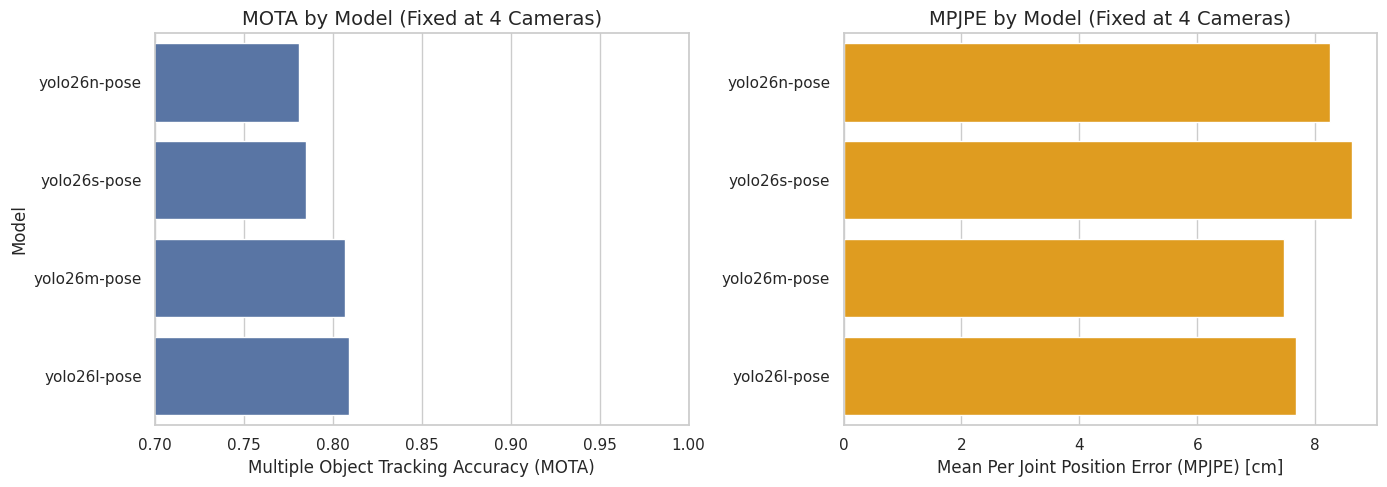

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MOTA comparison (higher is better)
ax = sns.barplot(
    data=df_4cams, x="MOTA", y="model", ax=axes[0], errorbar=None,
    order=["yolo26n-pose", "yolo26s-pose", "yolo26m-pose", "yolo26l-pose"]
)
axes[0].set_title("MOTA by Model (Fixed at 4 Cameras)")
axes[0].set_xlabel("Multiple Object Tracking Accuracy (MOTA)")
axes[0].set_ylabel("Model")
axes[0].set_xlim(0.70, 1.0)

# MPJPE comparison (lower is better)
sns.barplot(
    data=df_4cams, x="MPJPE", y="model", ax=axes[1], color="orange", errorbar=None,
    order=["yolo26n-pose", "yolo26s-pose", "yolo26m-pose", "yolo26l-pose"]
)
axes[1].set_title("MPJPE by Model (Fixed at 4 Cameras)")
axes[1].set_xlabel("Mean Per Joint Position Error (MPJPE) [cm]")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig("../../report/figures/model_comparison_4_cams.pdf")
plt.show()

Next let us analyze the efficacy of scaling up the number of used cameras.

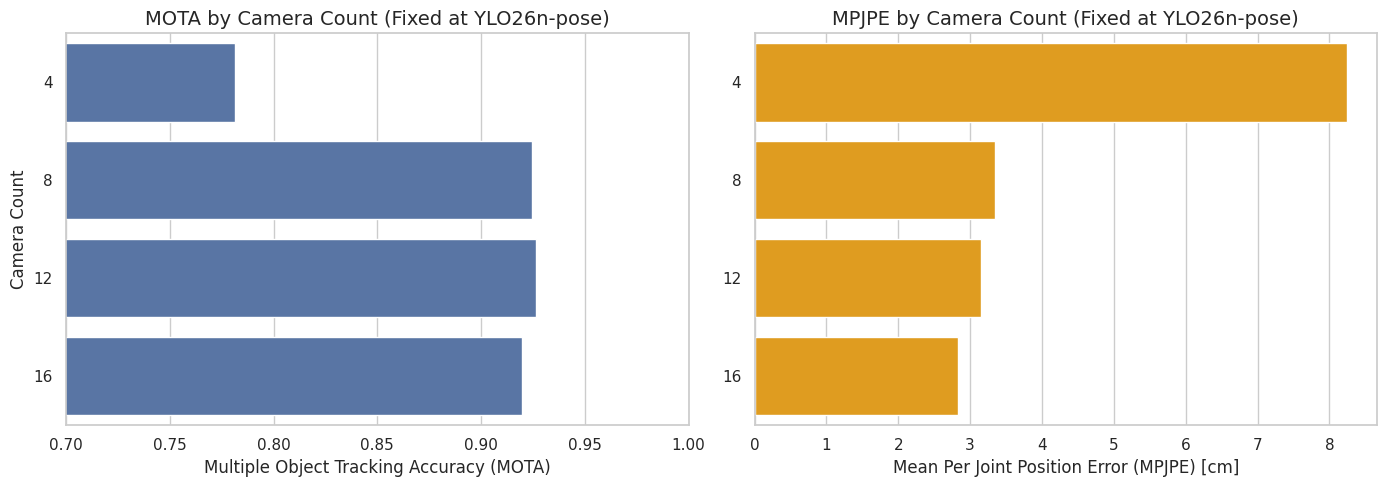

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MOTA comparison (higher is better)
ax = sns.barplot(
    data=df_yolo_scaling, x="MOTA", y="n_cams", ax=axes[0],
    errorbar=None, order=[4, 8, 12, 16], orient="h"
)
axes[0].set_title("MOTA by Camera Count (Fixed at YLO26n-pose)")
axes[0].set_xlabel("Multiple Object Tracking Accuracy (MOTA)")
axes[0].set_ylabel("Camera Count")
axes[0].set_xlim(0.70, 1.0)

# MPJPE comparison (lower is better)
sns.barplot(
    data=df_yolo_scaling, x="MPJPE", y="n_cams", ax=axes[1], color="orange",
    errorbar=None, order=[4, 8, 12, 16], orient="h"
)
axes[1].set_title("MPJPE by Camera Count (Fixed at YLO26n-pose)")
axes[1].set_xlabel("Mean Per Joint Position Error (MPJPE) [cm]")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig("../../report/figures/camera_count_comparison.pdf")
plt.show()

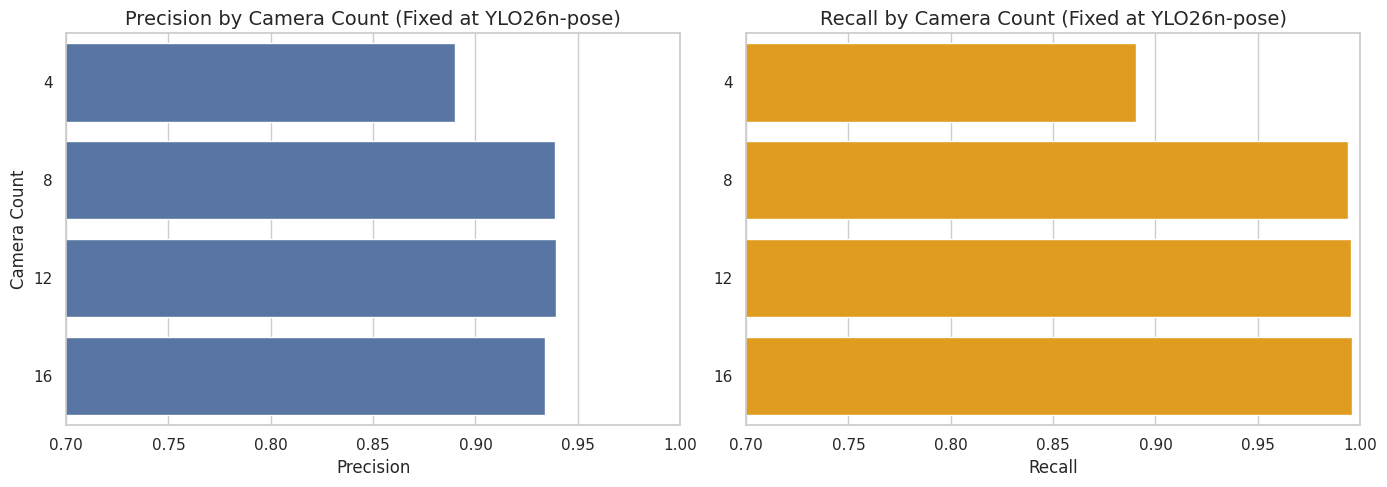

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precision comparison (higher is better)
ax = sns.barplot(
    data=df_yolo_scaling, x="Precision", y="n_cams", ax=axes[0],
    errorbar=None, order=[4, 8, 12, 16], orient="h"
)
axes[0].set_title("Precision by Camera Count (Fixed at YLO26n-pose)")
axes[0].set_xlabel("Precision")
axes[0].set_ylabel("Camera Count")
axes[0].set_xlim(0.7, 1.0)

# Recall comparison (higher is better)
sns.barplot(
    data=df_yolo_scaling, x="Recall", y="n_cams", ax=axes[1], color="orange",
    errorbar=None, order=[4, 8, 12, 16], orient="h"
)
axes[1].set_title("Recall by Camera Count (Fixed at YLO26n-pose)")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("")
axes[1].set_xlim(0.7, 1.0)

plt.tight_layout()
plt.savefig("../../report/figures/camera_count_comparison_precision.pdf")
plt.show()

Now let us look also at the runtime breakdown.

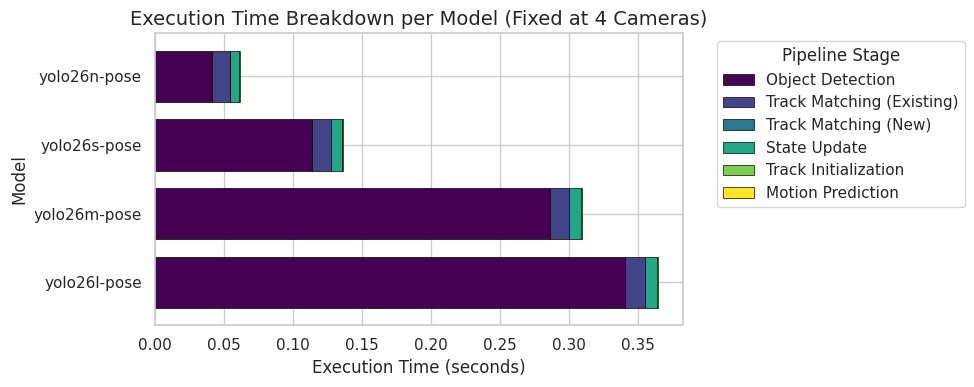

In [21]:
# Breaks down execution times across models under identical environment conditions.
time_cols = [
    "t_detection", "t_matching_old", "t_matching_new", "t_update", "t_create_new", "t_prediction"
]
kind_rename_map = {
    "t_detection": "Object Detection",
    "t_matching_old": "Track Matching (Existing)",
    "t_matching_new": "Track Matching (New)",
    "t_update": "State Update",
    "t_create_new": "Track Initialization",
    "t_prediction": "Motion Prediction"
}

df_time_sorted = df_4cams.groupby("model")[time_cols].mean()\
    .sort_values(by="t_detection", ascending=False)

ax = df_time_sorted[time_cols].plot(
    kind="barh", stacked=True, figsize=(10, 4),
    colormap="viridis", edgecolor="black", linewidth=0.5,
    width=0.75
)
handles, labels = ax.get_legend_handles_labels()

new_labels = [kind_rename_map.get(label, label) for label in labels]
plt.title("Execution Time Breakdown per Model (Fixed at 4 Cameras)")
plt.xlabel("Execution Time (seconds)")
plt.ylabel("Model")
plt.legend(handles, new_labels, title="Pipeline Stage",
           bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("../../report/figures/execution_time_breakdown_4_cams.pdf")
plt.show()

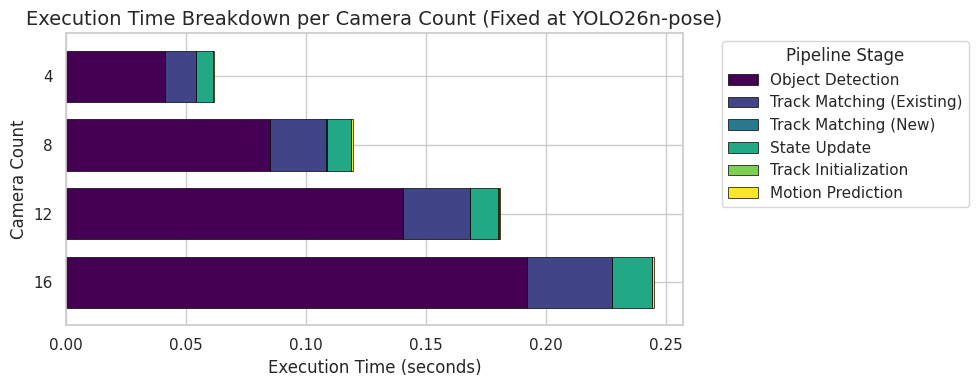

In [22]:
# Breaks down execution times across models under identical environment conditions.
time_cols = [
    "t_detection", "t_matching_old", "t_matching_new", "t_update", "t_create_new", "t_prediction"
]
kind_rename_map = {
    "t_detection": "Object Detection",
    "t_matching_old": "Track Matching (Existing)",
    "t_matching_new": "Track Matching (New)",
    "t_update": "State Update",
    "t_create_new": "Track Initialization",
    "t_prediction": "Motion Prediction"
}

df_time_sorted = df_yolo_scaling.groupby("n_cams")[time_cols].mean()\
    .sort_values(by="t_detection", ascending=False)

ax = df_time_sorted[time_cols].plot(
    kind="barh", stacked=True, figsize=(10, 4),
    colormap="viridis", edgecolor="black", linewidth=0.5,
    width=0.75
)
handles, labels = ax.get_legend_handles_labels()

new_labels = [kind_rename_map.get(label, label) for label in labels]
plt.title("Execution Time Breakdown per Camera Count (Fixed at YOLO26n-pose)")
plt.xlabel("Execution Time (seconds)")
plt.ylabel("Camera Count")
plt.legend(handles, new_labels, title="Pipeline Stage",
           bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("../../report/figures/execution_time_breakdown_cams.pdf")
plt.show()

Now we generate some tables for use in the report.

In [27]:
runtime_cols = [
    't_detection', 't_matching_old', 't_matching_new',
    't_update', 't_create_new', 't_prediction'
]
performance_cols = [
    'MOTA', 'MOTP', 'MPJPE', 'Precision', 'Recall'
]
df_performance = df.groupby(['model', 'n_cams'])[performance_cols].mean()

df_runtimes = df.groupby(['model', 'n_cams'])[runtime_cols].mean()
df_runtimes['t_total'] = df_runtimes.sum(axis=1)

df_scene_performance = df.groupby(['scene'])[performance_cols].mean()

print("=== PERFORMANCE METRICS TABLE ===")
print(df_performance.round(3).to_markdown())

print("\n=== RUNTIMES TABLE (seconds) ===")
print(df_runtimes.round(4).to_markdown())

print("\n=== SCENE DIFFICULTY ANALYSIS TABLE ===")
print(df_scene_performance.round(3).to_markdown())

=== PERFORMANCE METRICS TABLE ===
|                      |   MOTA |   MOTP |   MPJPE |   Precision |   Recall |
|:---------------------|-------:|-------:|--------:|------------:|---------:|
| ('yolo26l-pose', 4)  |  0.809 |  4.792 |   7.674 |       0.898 |    0.915 |
| ('yolo26m-pose', 4)  |  0.807 |  4.976 |   7.466 |       0.897 |    0.913 |
| ('yolo26n-pose', 4)  |  0.781 |  5.488 |   8.25  |       0.89  |    0.89  |
| ('yolo26n-pose', 8)  |  0.924 |  3.235 |   3.341 |       0.939 |    0.994 |
| ('yolo26n-pose', 12) |  0.926 |  3.066 |   3.146 |       0.939 |    0.996 |
| ('yolo26n-pose', 16) |  0.92  |  2.749 |   2.834 |       0.934 |    0.996 |
| ('yolo26s-pose', 4)  |  0.785 |  5.151 |   8.616 |       0.888 |    0.899 |

=== RUNTIMES TABLE (seconds) ===
|                      |   t_detection |   t_matching_old |   t_matching_new |   t_update |   t_create_new |   t_prediction |   t_total |
|:---------------------|--------------:|-----------------:|-----------------:|-----------:|-

#### Experiments using skeletal constraints

Next we perform some tests focused on using the physics model that incorporates skeletal constraints.

In [9]:
physics = tracker.build_constrained_physics()
physics.to(util.DEVICE)
detector = detect.PoseDetector(model_name="yolo26n-pose", path="../nets")
detector.to(util.DEVICE)

for scene in data.test_scenes:
    print(f"running for {scene}...")
    # Only perform if we don't have the result yet, to enable resuming.
    if not os.path.exists(f"../stats/eval/constrained/{scene}-times.json"):
        source = data.get_source(scene, num_vga_cams=4)
        source.to(util.DEVICE)
        track = tracker.Tracker(detector, physics)
        cams, frames, fps = track.evaluate(source, progress=0)
        util.save_tracks(
            f"../stats/eval/constrained/{scene}.json", cams, frames, fps)
        util.save_json(
            f"../stats/eval/constrained/{scene}-times.json", track.timing_stats)

running for 171026_pose3...
running for 160906_ian1...
running for 170915_office1...
running for 161029_build1...
running for 160224_haggling1...
running for 160906_pizza1...
running for 170221_haggling_m3...
running for 161029_sports1...


#### Experiments using learned components

Next we perform some tests that are replacing individual parts and also all parts at once with the components that have been learned from the dataset instead of hand tuned. We start by using the learned Kalman filter parameters.

In [10]:
physics = kalman.LearnedPhysics(tracker.build_constrained_physics())
physics.load_state_dict(torch.load("../nets/kalman/20.net"))
physics.to(util.DEVICE)
detector = detect.PoseDetector(model_name="yolo26n-pose", path="../nets")
detector.to(util.DEVICE)

for scene in data.test_scenes:
    print(f"running for {scene}...")
    # Only perform if we don't have the result yet, to enable resuming.
    if not os.path.exists(f"../stats/eval/lkalman/{scene}-times.json"):
        source = data.get_source(scene, num_vga_cams=4)
        source.to(util.DEVICE)
        track = tracker.Tracker(detector, physics)
        cams, frames, fps = track.evaluate(source, progress=0)
        util.save_tracks(
            f"../stats/eval/lkalman/{scene}.json", cams, frames, fps)
        util.save_json(
            f"../stats/eval/lkalman/{scene}-times.json", track.timing_stats)

running for 171026_pose3...
running for 160906_ian1...
running for 170915_office1...
running for 161029_build1...
running for 160224_haggling1...
running for 160906_pizza1...
running for 170221_haggling_m3...
running for 161029_sports1...


Now we test it by also adding the custom YOLO model.

In [6]:
physics = kalman.LearnedPhysics(tracker.build_constrained_physics())
physics.load_state_dict(torch.load("../nets/kalman/20.net"))
physics.to(util.DEVICE)
model = detect.CustomHeadedYolo(path="../nets")
model.load_state_dict(torch.load("../nets/yolo/103.net"))
detector = detect.CustomPoseDetector(model)
detector.to(util.DEVICE)

for scene in data.test_scenes:
    print(f"running for {scene}...")
    # Only perform if we don't have the result yet, to enable resuming.
    if not os.path.exists(f"../stats/eval/lkyolo/{scene}-times.json"):
        source = data.get_source(scene, num_vga_cams=4)
        source.to(util.DEVICE)
        track = tracker.Tracker(detector, physics)
        cams, frames, fps = track.evaluate(source, progress=0)
        util.save_tracks(
            f"../stats/eval/lkyolo/{scene}.json", cams, frames, fps)
        util.save_json(
            f"../stats/eval/lkyolo/{scene}-times.json", track.timing_stats)

running for 171026_pose3...
running for 160906_ian1...
running for 170915_office1...
running for 161029_build1...
running for 160224_haggling1...
running for 160906_pizza1...
running for 170221_haggling_m3...
running for 161029_sports1...


Let us also try with the non-learned constrained model but still using the custom YOLO model.

In [7]:
physics = tracker.build_constrained_physics()
physics.to(util.DEVICE)
model = detect.CustomHeadedYolo(path="../nets")
model.load_state_dict(torch.load("../nets/yolo/103.net"))
detector = detect.CustomPoseDetector(model)
detector.to(util.DEVICE)

for scene in data.test_scenes:
    print(f"running for {scene}...")
    # Only perform if we don't have the result yet, to enable resuming.
    if not os.path.exists(f"../stats/eval/yolo/{scene}-times.json"):
        source = data.get_source(scene, num_vga_cams=4)
        source.to(util.DEVICE)
        track = tracker.Tracker(detector, physics)
        cams, frames, fps = track.evaluate(source, progress=0)
        util.save_tracks(
            f"../stats/eval/yolo/{scene}.json", cams, frames, fps)
        util.save_json(
            f"../stats/eval/yolo/{scene}-times.json", track.timing_stats)

running for 171026_pose3...
running for 160906_ian1...
running for 170915_office1...
running for 161029_build1...
running for 160224_haggling1...
running for 160906_pizza1...
running for 170221_haggling_m3...
running for 161029_sports1...


Finally, we combine the above with the other tuned parameters.

In [7]:
physics = kalman.LearnedPhysics(tracker.build_constrained_physics())
physics.load_state_dict(torch.load("../nets/kalman/20.net"))
physics.to(util.DEVICE)
model = detect.CustomHeadedYolo(path="../nets")
model.load_state_dict(torch.load("../nets/yolo/103.net"))
detector = detect.CustomPoseDetector(model)
detector.to(util.DEVICE)

for scene in data.test_scenes:
    print(f"running for {scene}...")
    # Only perform if we don't have the result yet, to enable resuming.
    if not os.path.exists(f"../stats/eval/tuned/{scene}-times.json"):
        source = data.get_source(scene, num_vga_cams=4)
        source.to(util.DEVICE)
        track = tracker.Tracker(detector, physics)
        track.mo_threshold, track.mn_threshold = 2, -6
        cams, frames, fps = track.evaluate(source, progress=0)
        util.save_tracks(
            f"../stats/eval/tuned/{scene}.json", cams, frames, fps)
        util.save_json(
            f"../stats/eval/tuned/{scene}-times.json", track.timing_stats)

running for 171026_pose3...
running for 160906_ian1...
running for 170915_office1...
running for 161029_build1...
running for 160224_haggling1...
running for 160906_pizza1...
running for 170221_haggling_m3...
running for 161029_sports1...


#### Analysis of Skeletal Constraints and Learning Impact

Now that we have run all the experiments, we can analyze the result to compare them against the baseline.

In [8]:
for kind in ["constrained", "lkalman", "lkyolo", "yolo", "tuned"]:
    for scene in data.test_scenes:
        print(f"running for {scene} using {kind}...")
        metrics = util.evaluate_from_files(
            f"../stats/gt/{scene}.json", f"../stats/eval/{kind}/{scene}.json")
        util.save_json(
            f"../stats/eval/{kind}/{scene}-metrics.json", metrics)

running for 171026_pose3 using constrained...
running for 160906_ian1 using constrained...
running for 170915_office1 using constrained...
running for 161029_build1 using constrained...
running for 160224_haggling1 using constrained...
running for 160906_pizza1 using constrained...
running for 170221_haggling_m3 using constrained...
running for 161029_sports1 using constrained...
running for 171026_pose3 using lkalman...
running for 160906_ian1 using lkalman...
running for 170915_office1 using lkalman...
running for 161029_build1 using lkalman...
running for 160224_haggling1 using lkalman...
running for 160906_pizza1 using lkalman...
running for 170221_haggling_m3 using lkalman...
running for 161029_sports1 using lkalman...
running for 171026_pose3 using lkyolo...
running for 160906_ian1 using lkyolo...
running for 170915_office1 using lkyolo...
running for 161029_build1 using lkyolo...
running for 160224_haggling1 using lkyolo...
running for 160906_pizza1 using lkyolo...
running for 1

In [9]:
kind_rename_map = {
    "yolo26n-pose/4": "Baseline",
    "constrained": "Constraints",
    "lkalman": "Learned Kalman",
    "yolo": "Custom YOLO",
    "lkyolo": "LK + CY",
    "tuned": "Tuned",
}

df = []
for kind in ["yolo26n-pose/4", "constrained", "lkalman", "yolo", "lkyolo", "tuned"]:
    for scene in data.test_scenes:
        metrics = util.load_json(f"../stats/eval/{kind}/{scene}-metrics.json")
        times = util.load_json(f"../stats/eval/{kind}/{scene}-times.json")
        df.append({
            "kind": kind_rename_map[kind], "scene": scene,
            "MPJPE": metrics["MPJPE"], "MOTA": metrics["MOTA"],
            "MOTP": metrics["MOTP (Avg Miss Distance)"],
            "Precision": metrics["Precision"], "Recall": metrics["Recall"],
            "t_detection": times["detection"][0] / times["detection"][1],
            "t_matching_old": times["matching_old"][0] / times["matching_old"][1],
            "t_matching_new": times["matching_new"][0] / times["matching_new"][1],
            "t_update": times["update"][0] / times["update"][1],
            "t_create_new": times["create_new"][0] / times["create_new"][1],
            "t_prediction": times["prediction"][0] / times["prediction"][1],
        })
df_e: Any = pd.DataFrame(df)
df_e.to_csv("../stats/results_e.csv", index=False)

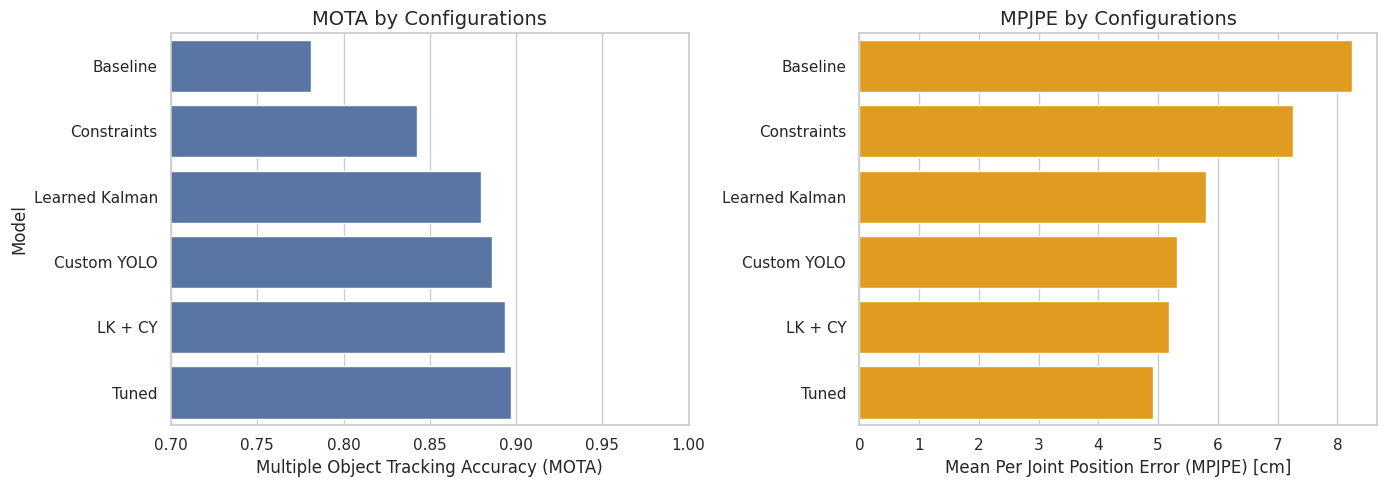

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MOTA comparison (higher is better)
ax = sns.barplot(
    data=df_e, x="MOTA", y="kind", ax=axes[0], errorbar=None,
    order=list(kind_rename_map.values())
)
axes[0].set_title("MOTA by Configurations")
axes[0].set_xlabel("Multiple Object Tracking Accuracy (MOTA)")
axes[0].set_ylabel("Model")
axes[0].set_xlim(0.70, 1.0)

# MPJPE comparison (lower is better)
sns.barplot(
    data=df_e, x="MPJPE", y="kind", ax=axes[1], color="orange", errorbar=None,
    order=list(kind_rename_map.values())
)
axes[1].set_title("MPJPE by Configurations")
axes[1].set_xlabel("Mean Per Joint Position Error (MPJPE) [cm]")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig("../../report/figures/improvements_comparison_4_cams.pdf")
plt.show()

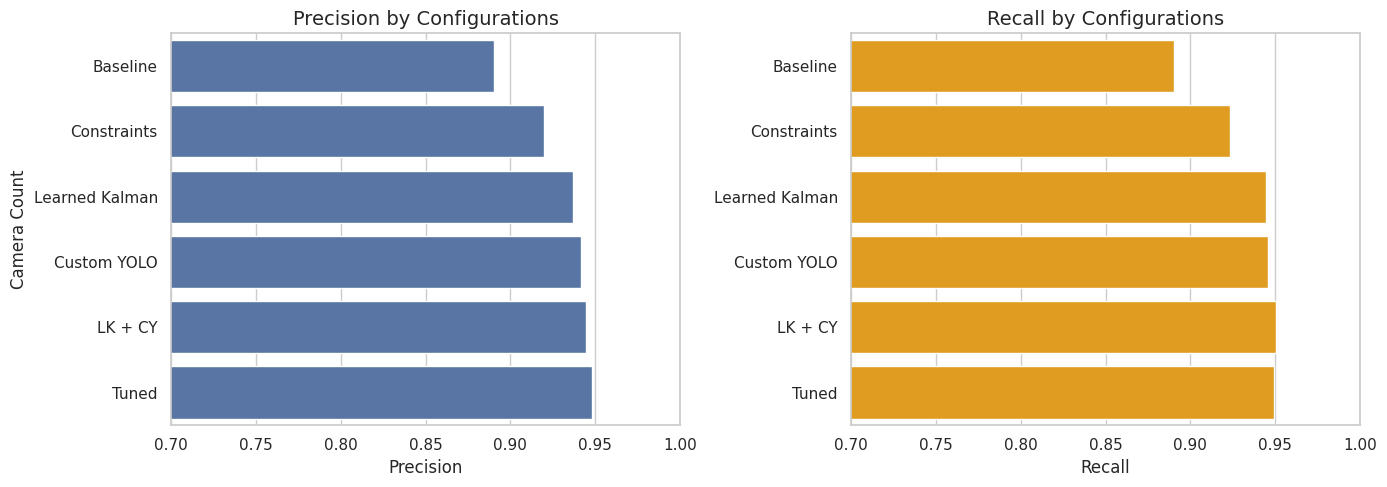

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precision comparison (higher is better)
ax = sns.barplot(
    data=df_e, x="Precision", y="kind", ax=axes[0],
    errorbar=None, order=list(kind_rename_map.values()), orient="h"
)
axes[0].set_title("Precision by Configurations")
axes[0].set_xlabel("Precision")
axes[0].set_ylabel("Camera Count")
axes[0].set_xlim(0.7, 1.00)

# Recall comparison (higher is better)
sns.barplot(
    data=df_e, x="Recall", y="kind", ax=axes[1], color="orange",
    errorbar=None, order=list(kind_rename_map.values()), orient="h"
)
axes[1].set_title("Recall by Configurations")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("")
axes[1].set_xlim(0.7, 1.00)

plt.tight_layout()
plt.savefig("../../report/figures/improvements_comparison_precision.pdf")
plt.show()

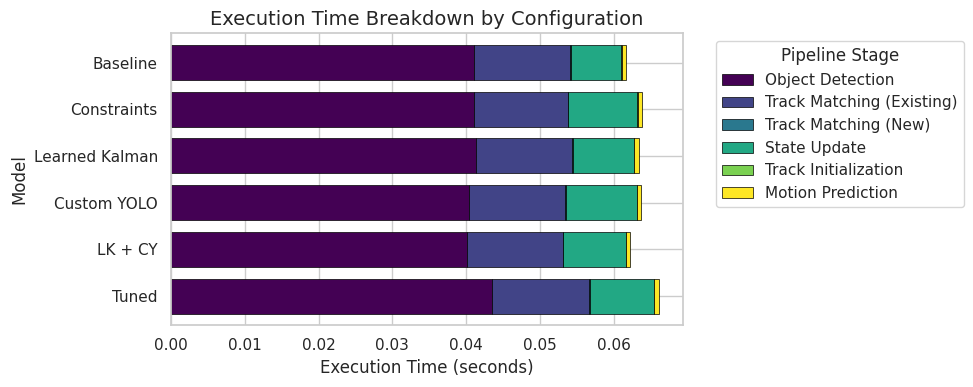

In [28]:
# Breaks down execution times across models under identical environment conditions.
order_dict = {
    "Baseline": 0, "Constraints": 1, "Learned Kalman": 2,
    "Custom YOLO": 3, "LK + CY": 4, "Tuned": 5,
}
df_time_sorted = df_e.groupby("kind")[time_cols].mean() \
    .sort_values(by="kind", key=lambda x: -x.map(order_dict))

ax = df_time_sorted[time_cols].plot(
    kind="barh", stacked=True, figsize=(10, 4),
    colormap="viridis", edgecolor="black", linewidth=0.5,
    width=0.75
)
handles, labels = ax.get_legend_handles_labels()

new_labels = [kind_rename_map.get(label, label) for label in labels]
plt.title("Execution Time Breakdown by Configuration")
plt.xlabel("Execution Time (seconds)")
plt.ylabel("Model")
plt.legend(handles, new_labels, title="Pipeline Stage",
           bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("../../report/figures/execution_time_breakdown_extensions.pdf")
plt.show()

In [32]:
performance_cols = [
    'MOTA', 'MOTP', 'MPJPE', 'Precision', 'Recall'
]
df_performance = df_e.groupby('kind')[performance_cols].mean() \
    .sort_values(by="kind", key=lambda x: x.map(order_dict))

print("=== PERFORMANCE METRICS TABLE ===")
print(df_performance.round(3).to_markdown())

=== PERFORMANCE METRICS TABLE ===
| kind           |   MOTA |   MOTP |   MPJPE |   Precision |   Recall |
|:---------------|-------:|-------:|--------:|------------:|---------:|
| Baseline       |  0.781 |  5.488 |   8.25  |       0.89  |    0.89  |
| Constraints    |  0.842 |  5.139 |   7.264 |       0.92  |    0.923 |
| Learned Kalman |  0.88  |  4.679 |   5.801 |       0.937 |    0.944 |
| Custom YOLO    |  0.886 |  3.788 |   5.318 |       0.941 |    0.946 |
| LK + CY        |  0.893 |  4.083 |   5.184 |       0.944 |    0.95  |
| Tuned          |  0.897 |  3.84  |   4.917 |       0.948 |    0.949 |


#### Qualitative Results

In this section we just look at some example sequence to compare how the differently configured tracking systems perform.

In [3]:
visualize.load_from_files(
    "../stats/eval/yolo26l-pose/4/160224_haggling1.json",
    "../stats/gt/160224_haggling1.json",
).show()

Widget(value='<iframe src="http://localhost:46221/index.html?ui=P_0x7f2eaa39d400_0&reconnect=auto" class="pyvi…

In [5]:
visualize.load_from_files(
    "../stats/eval/yolo26n-pose/8/160224_haggling1.json",
    "../stats/gt/160224_haggling1.json",
).show()

Widget(value='<iframe src="http://localhost:46221/index.html?ui=P_0x7f2e74f49590_1&reconnect=auto" class="pyvi…

In [6]:
visualize.load_from_files(
    "../stats/eval/tuned/160224_haggling1.json",
    "../stats/gt/160224_haggling1.json",
).show()

Widget(value='<iframe src="http://localhost:46221/index.html?ui=P_0x7f2e74f4aad0_2&reconnect=auto" class="pyvi…

In [7]:
visualize.load_from_files(
    "../stats/eval/yolo/160906_ian1.json",
    "../stats/gt/160906_ian1.json",
).show()

Widget(value='<iframe src="http://localhost:46221/index.html?ui=P_0x7f2df0d34cd0_3&reconnect=auto" class="pyvi…